---
## 1. Implementing the QFT, reminder of equations

### 1.1 Quantum Fourier Transform

The QFT on $n$ qubits maps computational basis states as:

$$|j\rangle \xrightarrow{\text{QFT}} \frac{1}{\sqrt{2^n}}
\sum_{k=0}^{2^n-1} e^{2\pi i jk/2^n}|k\rangle$$

The full matrix is $F_{jk} = \omega^{jk}/\sqrt{2^n}$ where $\omega = e^{2\pi i/2^n}$.

### 1.2 Circuit Decomposition

On a quantum computer the QFT is built from:

- **Hadamard gate**: $H = \frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$
- **Phase-rotation gates**: $R_k = \begin{pmatrix}1&0\\0&e^{2\pi i/2^k}\end{pmatrix}$
- **SWAP gates** for bit-reversal at the end

For qubit $j$, the circuit layer is:

$$H_j \;\cdot\; CR_2(j{+}1,j) \;\cdot\; CR_3(j{+}2,j) \;\cdots$$

Gate count: $n$ Hadamards $+$ $n(n{-}1)/2$ controlled-$R_k$ $+$ $\lfloor n/2 \rfloor$ SWAPs.

The **IQFT** reverses the circuit and replaces each $R_k \to R_k^\dagger = R_k^*$.


---
## 2. Imports & Shared Utilities

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product as iproduct
from scipy.linalg import eigh

# ── Colour palette ─────────────────────────────────────────────────
BG, PANEL  = "#0d0f1a", "#131629"
ACCENT     = "#4fc3f7"
WARM       = "#ff7043"
GREEN      = "#69f0ae"
PURPLE     = "#ce93d8"
GRID       = "#1e2340"
TEXT       = "#e8eaf6"
PINK       = "#f48fb1"

def dark_style():
    plt.rcParams.update({
        'figure.facecolor': BG,    'axes.facecolor':  PANEL,
        'axes.edgecolor':   GRID,  'axes.labelcolor': TEXT,
        'xtick.color':      TEXT,  'ytick.color':     TEXT,
        'text.color':       TEXT,  'grid.color':      GRID,
        'grid.linewidth':   0.6,   'legend.facecolor':PANEL,
        'legend.edgecolor': GRID,
    })

dark_style()
print("Imports OK — NumPy", np.__version__)


Imports OK — NumPy 1.22.3


---
## 3. Analytic QFT Matrix

The closed-form matrix $F_{jk} = e^{2\pi i jk/2^n}/\sqrt{2^n}$ from `qft.py`.


In [14]:
def analytic_qft(n):
    """Closed-form QFT matrix: F[j,k] = omega^(jk) / sqrt(2^n)."""
    dim   = 2 ** n
    omega = np.exp(2j * np.pi / dim)
    idx   = np.arange(dim)
    return np.power(omega, np.outer(idx, idx)) / np.sqrt(dim)

def analytic_iqft(n):
    """Closed-form IQFT = QFT†."""
    return analytic_qft(n).conj()

# Test on n=4
n = 4
F  = analytic_qft(n)
Fd = analytic_iqft(n)

print(f"QFT shape:              {F.shape}")
print(f"Max |F·F† − I|:         {np.max(np.abs(F @ Fd - np.eye(2**n))):.3e}")
print(f"Max |IQFT − QFT†|:      {np.max(np.abs(Fd - F.conj().T)):.3e}")
print(f"All |F_jk| = 1/√{2**n}:  {np.allclose(np.abs(F), 1/np.sqrt(2**n))}")


QFT shape:              (16, 16)
Max |F·F† − I|:         1.841e-15
Max |IQFT − QFT†|:      0.000e+00
All |F_jk| = 1/√16:  True


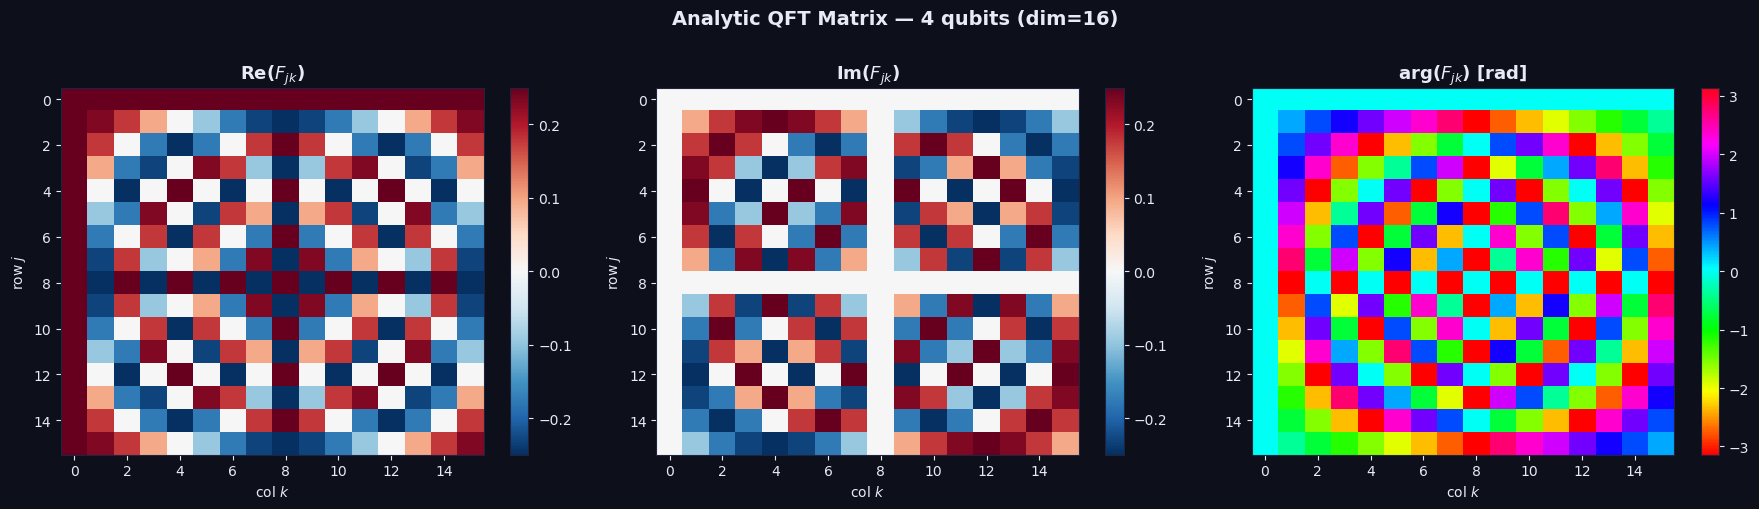

In [15]:
# Visualise QFT matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_vis = 4; F_vis = analytic_qft(n_vis)
for ax_i, (data, cmap, title) in zip(axes, [
    (F_vis.real,       'RdBu_r', 'Re($F_{jk}$)'),
    (F_vis.imag,       'RdBu_r', 'Im($F_{jk}$)'),
    (np.angle(F_vis),  'hsv',    'arg($F_{jk}$) [rad]'),
]):
    vabs = max(np.abs(data).max(), 1e-16)
    im = ax_i.imshow(data, cmap=cmap, vmin=-vabs, vmax=vabs,
                     interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax_i)
    ax_i.set_title(title, fontweight='bold', color=TEXT, fontsize=13)
    ax_i.set_xlabel('col $k$'); ax_i.set_ylabel('row $j$')
plt.suptitle(f'Analytic QFT Matrix — {n_vis} qubits (dim={2**n_vis})',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout(); plt.show()


---
## 4. Object-Oriented QFT / IQFT

Encapsulates the QFT as a class with a `QuantumState` wrapper.


In [16]:
class QuantumState:
    """n-qubit complex state vector with convenience constructors."""
    def __init__(self, amplitudes, label=''):
        self._vec = np.asarray(amplitudes, dtype=complex)
        self._n   = int(round(np.log2(len(self._vec))))
        self.label = label

    @classmethod
    def computational_basis(cls, idx, n):
        v = np.zeros(2**n, dtype=complex); v[idx] = 1.0
        return cls(v, label=f'|{idx}⟩')

    @classmethod
    def random(cls, n, seed=None):
        rng = np.random.default_rng(seed)
        v   = rng.standard_normal(2**n) + 1j*rng.standard_normal(2**n)
        return cls(v / np.linalg.norm(v), label='random')

    @property
    def n_qubits(self): return self._n
    @property
    def amplitudes(self): return self._vec.copy()
    @property
    def probabilities(self): return np.abs(self._vec)**2
    @property
    def norm(self): return float(np.linalg.norm(self._vec))


class _FourierBase:
    _sign = +1; _label = 'F'
    def __init__(self, n):
        self._n = n; self._dim = 2**n; self._mat = None
    def _build(self):
        dim = self._dim
        idx = np.arange(dim)
        return np.power(np.exp(self._sign*2j*np.pi/dim),
                        np.outer(idx, idx)) / np.sqrt(dim)
    @property
    def matrix(self):
        if self._mat is None: self._mat = self._build()
        return self._mat
    def apply(self, state):
        return QuantumState(self.matrix @ state.amplitudes,
                            label=f'{self._label}({state.label})')
    def __call__(self, state): return self.apply(state)


class QFTOperator(_FourierBase):
    _sign = +1; _label = 'QFT'

class IQFTOperator(_FourierBase):
    _sign = -1; _label = 'IQFT'

# Test
n = 4
qft_op  = QFTOperator(n)
iqft_op = IQFTOperator(n)
s5      = QuantumState.computational_basis(5, n)
s_out   = qft_op(s5)
s_back  = iqft_op(s_out)
fid     = abs(np.vdot(s5.amplitudes, s_back.amplitudes))**2

print(f"Input:              {s5.label}")
print(f"After QFT:          {s_out.label}  (norm={s_out.norm:.10f})")
print(f"Round-trip fidelity = {fid:.15f}")
print(f"IQFT = QFT†?        {np.allclose(iqft_op.matrix, qft_op.matrix.conj().T)}")


Input:              |5⟩
After QFT:          QFT(|5⟩)  (norm=1.0000000000)
Round-trip fidelity = 1.000000000000000
IQFT = QFT†?        True


---
## 5. Gate-Circuit QFT / IQFT

Builds the QFT by composing Hadamard, controlled-$R_k$, and SWAP gates
as embedded $2^n \times 2^n$ unitaries — exactly as on a real quantum computer.


In [17]:
# ── Single-qubit gate matrices ────────────────────────────────────
def _H():
    return np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)

def _R(k):
    """R_k = diag(1, exp(2πi/2^k))."""
    return np.array([[1,0],[0,np.exp(2j*np.pi/(2**k))]], dtype=complex)

def _Rd(k):
    return _R(k).conj().T

# ── Embedding into n-qubit space ──────────────────────────────────
def embed_single(n, qubit, gate2):
    ops = [np.eye(2,dtype=complex)]*n; ops[qubit]=gate2
    r=ops[0]
    for op in ops[1:]: r=np.kron(r,op)
    return r

def embed_controlled(n, ctrl, tgt, gate2):
    P0=np.array([[1,0],[0,0]],dtype=complex)
    P1=np.array([[0,0],[0,1]],dtype=complex)
    def branch(proj, g):
        ops=[np.eye(2,dtype=complex)]*n; ops[ctrl]=proj; ops[tgt]=g
        r=ops[0]
        for op in ops[1:]: r=np.kron(r,op)
        return r
    return branch(P0,np.eye(2,dtype=complex)) + branch(P1,gate2)

def embed_swap(n, i, j):
    X=np.array([[0,1],[1,0]],dtype=complex)
    c=lambda a,b: embed_controlled(n,a,b,X)
    return c(i,j)@c(j,i)@c(i,j)

# ── Circuit construction ──────────────────────────────────────────
def qft_circuit(n):
    """Build n-qubit QFT from H + CR_k + SWAP gates."""
    U = np.eye(2**n, dtype=complex)
    for j in range(n):
        U = embed_single(n, j, _H()) @ U
        for m in range(j+1, n):
            U = embed_controlled(n, m, j, _R(m-j+1)) @ U
    for i in range(n//2):
        U = embed_swap(n, i, n-1-i) @ U
    return U

def iqft_circuit(n):
    """Build n-qubit IQFT (reversed circuit, R_k → R_k†)."""
    U = np.eye(2**n, dtype=complex)
    for i in range(n//2):
        U = embed_swap(n, i, n-1-i) @ U
    for j in range(n-1, -1, -1):
        for m in range(n-1, j, -1):
            U = embed_controlled(n, m, j, _Rd(m-j+1)) @ U
        U = embed_single(n, j, _H()) @ U
    return U

# Test
n = 3
U_circ = qft_circuit(n)
U_iqft = iqft_circuit(n)
U_ref  = analytic_qft(n)
I      = np.eye(2**n)

print(f"n={n} qubits (dim={2**n})")
print(f"  Max |U·U† − I|:           {np.max(np.abs(U_circ@U_circ.conj().T-I)):.3e}")
print(f"  Max |IQFT·QFT − I|:       {np.max(np.abs(U_iqft@U_circ-I)):.3e}")
print(f"  Max |circuit − analytic|:  {np.max(np.abs(U_circ-U_ref)):.3e}")


n=3 qubits (dim=8)
  Max |U·U† − I|:           6.661e-16
  Max |IQFT·QFT − I|:       6.661e-16
  Max |circuit − analytic|:  1.905e-15


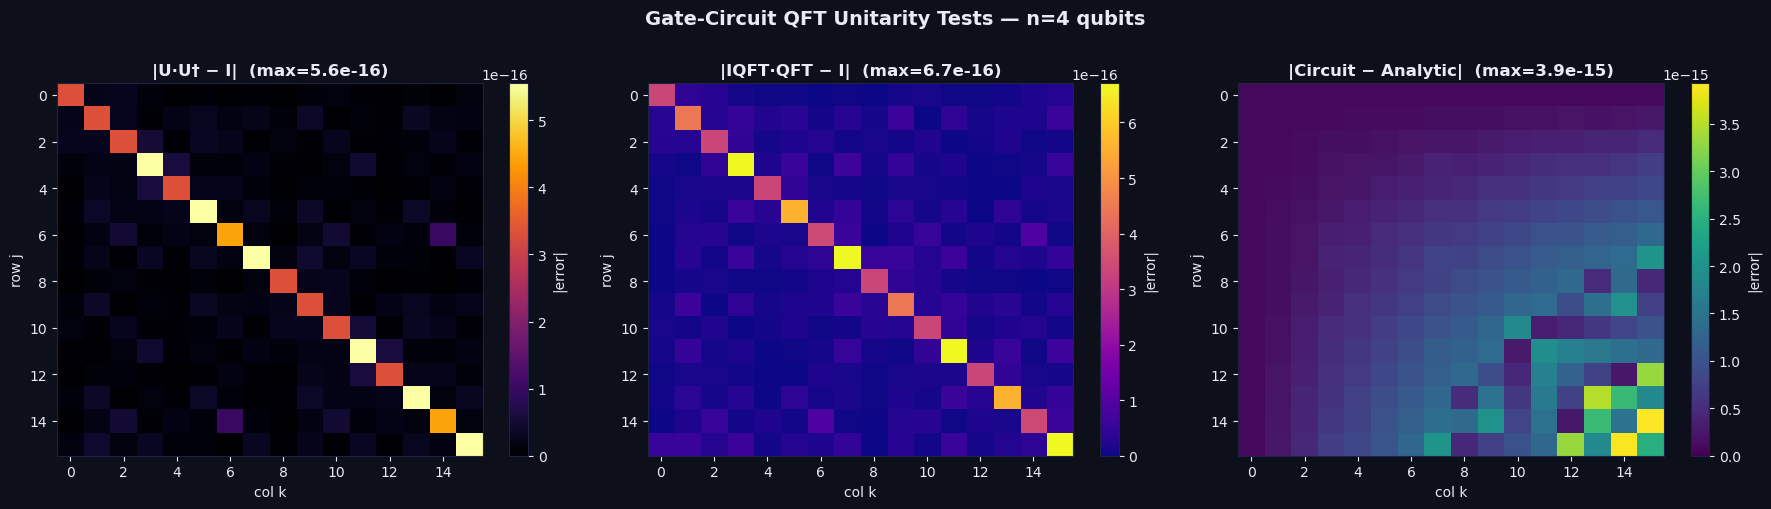

In [18]:
# Unitarity tests for n=3 and n=4
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_test = 4
Uc = qft_circuit(n_test)
Ui = iqft_circuit(n_test)
In = np.eye(2**n_test)

for ax_i, (data, cmap, title) in zip(axes, [
    (np.abs(Uc @ Uc.conj().T - In), 'inferno', f'|U·U† − I|  (max={np.max(np.abs(Uc@Uc.conj().T-In)):.1e})'),
    (np.abs(Ui @ Uc - In),          'plasma',  f'|IQFT·QFT − I|  (max={np.max(np.abs(Ui@Uc-In)):.1e})'),
    (np.abs(Uc - analytic_qft(n_test)), 'viridis', f'|Circuit − Analytic|  (max={np.max(np.abs(Uc-analytic_qft(n_test))):.1e})'),
]):
    im = ax_i.imshow(data, cmap=cmap, vmin=0, vmax=max(data.max(),1e-16),
                     interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax_i, label='|error|')
    ax_i.set_title(title, fontweight='bold', color=TEXT)
    ax_i.set_xlabel('col k'); ax_i.set_ylabel('row j')

plt.suptitle(f'Gate-Circuit QFT Unitarity Tests — n={n_test} qubits',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout(); plt.show()
